In [80]:
from pathlib import Path
import json
import pandas as pd
import re

# ===== CONFIG =====
ROOT_DIR = Path("../data/processed/ner_predictions/")
MANIFEST_PATH = Path("../data/processed/manifests/ner_manifest_mapped.jsonl")
LABELS_WHITELIST = True
PII_LABELS = {"PER", "LOC", "ORG"}

# ==================

In [81]:
# =========================
# HELPERS
# =========================
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def load_jsonl_df(path):
    return pd.DataFrame(load_jsonl(path))

def load_all_predictions(root_dir, excluded_dirs=None):
    all_rows = []
    for subdir in root_dir.iterdir():
        if not subdir.is_dir():
            continue

        if subdir.name in excluded_dirs:
            continue

        for file in subdir.glob("*.jsonl"):
            model_name = file.stem
            data = load_jsonl(file)

            for row in data:
                row["model_name"] = model_name
                row["source_file"] = str(file.relative_to(root_dir))
                all_rows.append(row)

    return pd.DataFrame(all_rows)

def normalize_text(s):
    if pd.isna(s) or s is None:
        return None
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

# =========================
# LOAD
# =========================
manifest_df = load_jsonl_df(MANIFEST_PATH)
pred_df = load_all_predictions(ROOT_DIR, {"llm_prompted_ner", "speech_aware"})

In [82]:
# =========================
# EXPLODE GOLD
# =========================
def explode_manifest_entities(df):
    rows = []
    for _, row in df.iterrows():
        for ent in row.get("entities", []):
            rows.append({
                "segment_id": row["segment_id"],
                "meeting_id": row.get("meeting_id"),
                "speaker_id": row.get("speaker_id"),
                "text": row.get("text"),
                "entity_text": ent.get("text"),
                "entity_text_norm": normalize_text(ent.get("text")),
                "start_char": ent.get("start_char"),
                "end_char": ent.get("end_char"),
                "raw_label": ent.get("label"),
                "std_label": ent.get("std_label"),
            })
    return pd.DataFrame(rows)

In [83]:
# =========================
# EXPLODE PREDICTIONS
# =========================
LABEL_MAP = {
    "person": "PER",
    "location": "LOC",
    "company": "ORG",
    "date": "DATE",
    "time": "TIME",
    "money": "MONEY",
}

def explode_predictions(df):
    rows = []
    for _, row in df.iterrows():
        for ent in row.get("predicted_entities", []):
            raw_label = ent.get("label")
            mapped_label = LABEL_MAP.get(raw_label, raw_label)

            rows.append({
                "model_name": row["model_name"],
                "source_file": row.get("source_file"),
                "segment_id": row["segment_id"],
                "meeting_id": row.get("meeting_id"),
                "speaker_id": row.get("speaker_id"),
                "text": row.get("text"),
                "entity_text": ent.get("text"),
                "entity_text_norm": normalize_text(ent.get("text")),
                "start_char": ent.get("start_char"),
                "end_char": ent.get("end_char"),
                "raw_label": raw_label,
                "std_label": mapped_label,
                "score": ent.get("score"),
                "latency_ms": row.get("latency_ms"),
            })
    return pd.DataFrame(rows)

gold_entities_df = explode_manifest_entities(manifest_df)
pred_entities_df = explode_predictions(pred_df)


In [84]:
# =========================
# DEDUPLICATE
# =========================
gold_entities_df = gold_entities_df.drop_duplicates(
    subset=["segment_id", "start_char", "end_char", "std_label", "entity_text_norm"]
).copy()

pred_entities_df = pred_entities_df.drop_duplicates(
    subset=["model_name", "segment_id", "start_char", "end_char", "std_label", "entity_text_norm"]
).copy()

In [85]:
# =========================
# LABEL WHITELIST
# =========================
if LABELS_WHITELIST:
    gold_entities_eval_df = gold_entities_df[
        gold_entities_df["std_label"].isin(PII_LABELS)
    ].copy()

    pred_entities_eval_df = pred_entities_df[
        pred_entities_df["std_label"].isin(PII_LABELS)
    ].copy()
else:
    gold_entities_eval_df = gold_entities_df.copy()
    pred_entities_eval_df = pred_entities_df.copy()

print("Gold entities for eval:", gold_entities_eval_df.shape)
print("Pred entities for eval:", pred_entities_eval_df.shape)


Gold entities for eval: (1275, 10)
Pred entities for eval: (19772, 14)


In [86]:
# =========================
# 1) STRICT TYPED EVALUATION
# exact match on:
# segment_id + start_char + end_char + std_label
# =========================
def compute_strict_typed_metrics(gold_df, pred_df):
    gold_keys = gold_df[
        ["segment_id", "start_char", "end_char", "std_label"]
    ].drop_duplicates()

    results = []

    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[
            ["segment_id", "start_char", "end_char", "std_label"]
        ].drop_duplicates()

        tp = len(pred_keys.merge(
            gold_keys,
            on=["segment_id", "start_char", "end_char", "std_label"],
            how="inner"
        ))

        fp = len(pred_keys) - tp
        fn = len(gold_keys) - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        results.append({
            "model_name": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

strict_df = compute_strict_typed_metrics(
    gold_entities_eval_df,
    pred_entities_eval_df
)

print("\nStrict typed metrics:")
display(strict_df)



Strict typed metrics:


,model_name,tp,fp,fn,precision,recall,f1
0,ner-large_predictions,691,740,584,0.482879,0.541961,0.510717
1,flair_ner-english-large_predictions,691,740,584,0.482879,0.541961,0.510717
2,dbmdz_bert-large-cased-finetuned-conll03-english_predictions,689,1032,586,0.400349,0.540392,0.459947
3,dslim_bert-base-NER_predictions,591,920,684,0.391132,0.463529,0.424264
4,Jean-Baptiste_roberta-large-ner-english_predictions,728,1455,547,0.333486,0.570980,0.421053
5,ner-fast_predictions,576,1300,699,0.307036,0.451765,0.365598
6,ner_predictions,626,2670,649,0.189927,0.490980,0.273901
7,elastic_distilbert-base-cased-finetuned-conll03-english_predictions,559,4334,716,0.114245,0.438431,0.181258
8,flair_ner-english-ontonotes_predictions,68,110,1207,0.382022,0.053333,0.093599
9,Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions,42,1210,1233,0.033546,0.032941,0.033241


In [87]:
# =========================
# 2) RELAXED TEXT+LABEL EVALUATION
# match on:
# segment_id + normalized entity text + std_label
# =========================
def compute_text_label_metrics(gold_df, pred_df):
    gold_keys = gold_df[
        ["segment_id", "entity_text_norm", "std_label"]
    ].drop_duplicates()

    results = []

    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[
            ["segment_id", "entity_text_norm", "std_label"]
        ].drop_duplicates()

        tp = len(pred_keys.merge(
            gold_keys,
            on=["segment_id", "entity_text_norm", "std_label"],
            how="inner"
        ))

        fp = len(pred_keys) - tp
        fn = len(gold_keys) - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        results.append({
            "model_name": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

relaxed_df = compute_text_label_metrics(
    gold_entities_eval_df,
    pred_entities_eval_df
)

print("\nRelaxed text+label metrics:")
display(relaxed_df)


Relaxed text+label metrics:


,model_name,tp,fp,fn,precision,recall,f1
0,Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions,707,502,568,0.584781,0.554510,0.569243
1,flair_ner-english-large_predictions,694,693,581,0.500360,0.544314,0.521412
2,ner-large_predictions,694,693,581,0.500360,0.544314,0.521412
3,dbmdz_bert-large-cased-finetuned-conll03-english_predictions,690,980,585,0.413174,0.541176,0.468591
4,dslim_bert-base-NER_predictions,594,864,681,0.407407,0.465882,0.434687
5,Jean-Baptiste_roberta-large-ner-english_predictions,730,1394,545,0.343691,0.572549,0.429538
6,ner-fast_predictions,580,1266,695,0.314193,0.454902,0.371676
7,ner_predictions,628,2623,647,0.193171,0.492549,0.277508
8,elastic_distilbert-base-cased-finetuned-conll03-english_predictions,561,4070,714,0.121140,0.440000,0.189976
9,flair_ner-english-ontonotes_predictions,69,108,1206,0.389831,0.054118,0.095041


In [88]:
# =========================
# RELAXED TEXT-ONLY EVALUATION
# match on:
# segment_id + normalized entity text
# =========================
def compute_text_only_metrics(gold_df, pred_df):
    gold_keys = gold_df[
        ["segment_id", "entity_text_norm"]
    ].drop_duplicates()

    results = []

    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[
            ["segment_id", "entity_text_norm"]
        ].drop_duplicates()

        tp = len(pred_keys.merge(
            gold_keys,
            on=["segment_id", "entity_text_norm"],
            how="inner"
        ))

        fp = len(pred_keys) - tp
        fn = len(gold_keys) - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        results.append({
            "model_name": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

text_only_df = compute_text_only_metrics(
    gold_entities_eval_df,
    pred_entities_eval_df
)

print("\nText-only (no label) metrics:")
display(text_only_df)


Text-only (no label) metrics:


,model_name,tp,fp,fn,precision,recall,f1
0,Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions,722,485,553,0.598177,0.566275,0.581789
1,flair_ner-english-large_predictions,711,676,564,0.512617,0.557647,0.534185
2,ner-large_predictions,711,676,564,0.512617,0.557647,0.534185
3,dbmdz_bert-large-cased-finetuned-conll03-english_predictions,711,959,564,0.425749,0.557647,0.482852
4,dslim_bert-base-NER_predictions,615,841,660,0.422390,0.482353,0.450384
5,Jean-Baptiste_roberta-large-ner-english_predictions,757,1366,518,0.356571,0.593725,0.445556
6,ner-fast_predictions,606,1239,669,0.328455,0.475294,0.388462
7,ner_predictions,646,2604,629,0.198769,0.506667,0.285525
8,elastic_distilbert-base-cased-finetuned-conll03-english_predictions,684,3939,591,0.147956,0.536471,0.231943
9,flair_ner-english-ontonotes_predictions,81,96,1194,0.457627,0.063529,0.111570


In [93]:
# =========================
# CLEAN MODEL NAMES
# =========================
CLEAN_NAMES = {
    "flair_ner-english-large_predictions": "Flair (Large)",
    "flair_ner-english-ontonotes_predictions": "Flair (OntoNotes)",
    "ner_predictions": "BiLSTM-CRF",
    "ner-fast_predictions": "BiLSTM-CRF (Fast)",
    "ner-large_predictions": "BiLSTM-CRF (Large)",
    "dbmdz_bert-large-cased-finetuned-conll03-english_predictions": "BERT (Large)",
    "dslim_bert-base-NER_predictions": "BERT (Base)",
    "elastic_distilbert-base-cased-finetuned-conll03-english_predictions": "DistilBERT",
    "Jean-Baptiste_roberta-large-ner-english_predictions": "RoBERTa (Large)",
    "Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions": "DeBERTa (Large)",
    "philter": "Philter",
}

# Apply clean names
text_only_df["model"] = text_only_df["model_name"].map(CLEAN_NAMES)

# Keep only needed columns + round
clean_metrics_df = (
    text_only_df[["model", "precision", "recall", "f1"]]
    .copy()
    .round(3)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

print("\nCleaned strict metrics:")
display(clean_metrics_df)


Cleaned strict metrics:


,model,precision,recall,f1
0,DeBERTa (Large),0.598,0.566,0.582
1,Flair (Large),0.513,0.558,0.534
2,BiLSTM-CRF (Large),0.513,0.558,0.534
3,BERT (Large),0.426,0.558,0.483
4,BERT (Base),0.422,0.482,0.450
5,RoBERTa (Large),0.357,0.594,0.446
6,BiLSTM-CRF (Fast),0.328,0.475,0.388
7,BiLSTM-CRF,0.199,0.507,0.286
8,DistilBERT,0.148,0.536,0.232
9,Flair (OntoNotes),0.458,0.064,0.112


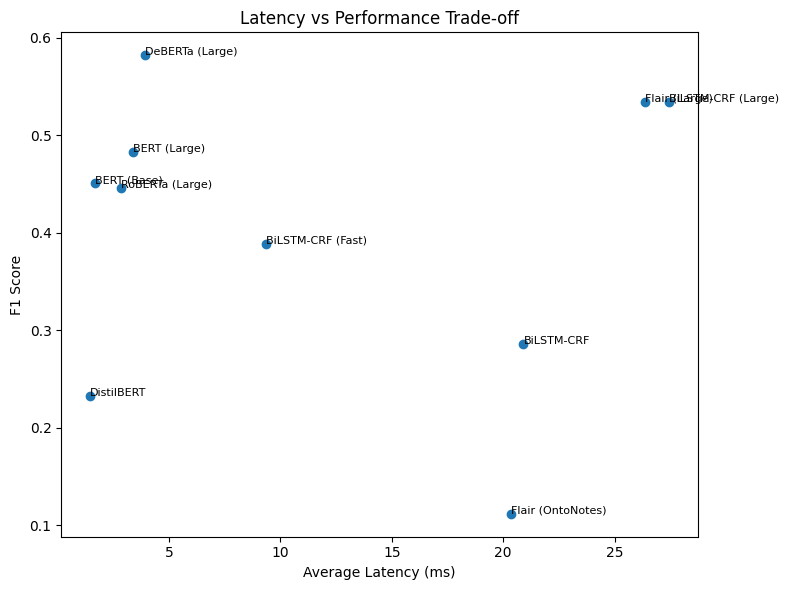

In [96]:
import matplotlib.pyplot as plt

# =========================
# CLEAN MODEL NAMES
# =========================
CLEAN_NAMES = {
    "flair_ner-english-large_predictions": "Flair (Large)",
    "flair_ner-english-ontonotes_predictions": "Flair (OntoNotes)",
    "ner_predictions": "BiLSTM-CRF",
    "ner-fast_predictions": "BiLSTM-CRF (Fast)",
    "ner-large_predictions": "BiLSTM-CRF (Large)",
    "dbmdz_bert-large-cased-finetuned-conll03-english_predictions": "BERT (Large)",
    "dslim_bert-base-NER_predictions": "BERT (Base)",
    "elastic_distilbert-base-cased-finetuned-conll03-english_predictions": "DistilBERT",
    "Jean-Baptiste_roberta-large-ner-english_predictions": "RoBERTa (Large)",
    "Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions": "DeBERTa (Large)",
}

# =========================
# LATENCY
# =========================
latency_df = (
    pred_df.groupby("model_name")["latency_ms"]
    .mean()
    .reset_index()
)

# =========================
# MERGE WITH F1
# =========================
merged = latency_df.merge(text_only_df, on="model_name")

# Clean names
merged["model"] = merged["model_name"].map(CLEAN_NAMES)

# Drop anything unmapped (e.g., excluded models)
merged = merged.dropna(subset=["model"])

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(merged["latency_ms"], merged["f1"])

# Add labels
for _, row in merged.iterrows():
    plt.text(row["latency_ms"], row["f1"], row["model"], fontsize=8)

plt.xlabel("Average Latency (ms)")
plt.ylabel("F1 Score")
plt.title("Latency vs Performance Trade-off")
plt.tight_layout()
plt.show()